# Project 1: Centrality in NYC’s Subway Shared-Service Network

**Anthony Josue Roman**  
**DATA 620: Web Analytics**

## Introduction

This study analyzes the connectedness of subway stations in Manhattan, Brooklyn, Queens, and the Bronx, utilizing the MTA Subway Stations data set. Staten Island Railway will not be included.

The nodes consist of the station ID. Nodes are connected when two stations have at least one common daytime route. This means that they operate on the same train service and are connected because of that. In case of transfer complexes with different station IDs, they are not considered the same node.

The degree centrality and eigenvector centrality are computed for each station. Degree centrality is the ratio of other stations connected to that station. Eigenvector centrality depends on the centrality of these stations.

## Research Question

How do degree centrality and eigenvector centrality in NYC’s subway shared-service network differ across boroughs?

## Network Definition

- **Nodes:** Individual subway station IDs.
- **Edges:** Connections between stations sharing at least one daytime route.
- **Graph type:** Undirected and unweighted, without self-loops or duplicate edges.
- **Categorical attribute:** Borough.
- **Scope:** Manhattan, Brooklyn, Queens, and the Bronx.

A shared route does not necessarily mean that every scheduled train serves both stations. Centrality in this network reflects shared-service connectivity, not service frequency, passenger volume, or travel time.

## Data Source

Metropolitan Transportation Authority. *MTA Subway Stations*. New York State Open Data.

https://data.ny.gov/Transportation/MTA-Subway-Stations/39hk-dx4f

In [1]:
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timezone
from itertools import combinations
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Data Collection

Station records are retrieved from the New York State Open Data API using pagination. The retrieval time is recorded because station information and route assignments may change.

The raw records are inspected before selecting and cleaning the fields needed for the network.

In [2]:
url = "https://data.ny.gov/resource/39hk-dx4f.json"

records = []
page_size = 1000
offset = 0

retrieved_at = datetime.now(timezone.utc).isoformat()

with requests.Session() as session:
    while True:
        params = {
            "$limit": page_size,
            "$offset": offset,
            "$order": ":id"
        }

        response = session.get(url, params=params, timeout=60)
        response.raise_for_status()

        batch = response.json()

        if not isinstance(batch, list):
            raise ValueError("The API did not return a list of station records.")

        records.extend(batch)

        if len(batch) < page_size:
            break

        offset += page_size

if not records:
    raise ValueError("No station records were returned.")

stations_raw = pd.DataFrame(records)

print(f"Retrieved at (UTC): {retrieved_at}")
print(f"Records retrieved: {len(stations_raw):,}")
print(f"Columns: {stations_raw.shape[1]}")

stations_raw.head()

Retrieved at (UTC): 2026-10-04T21:01:27.915366+00:00
Records retrieved: 496
Columns: 19


,gtfs_stop_id,station_id,complex_id,division,line,stop_name,borough,cbd,daytime_routes,structure,gtfs_latitude,gtfs_longitude,north_direction_label,south_direction_label,ada,ada_northbound,ada_southbound,ada_notes,georeference
0,F33,248,248,IND,6th Av - Culver,Avenue N,Bk,false,F,Elevated,40.61514,-73.974197,Manhattan,Southbound,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.974197, ..."
1,F34,249,249,IND,6th Av - Culver,Avenue P,Bk,false,F,Elevated,40.608944,-73.973022,Manhattan,Southbound,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.973022, ..."
2,F35,250,250,IND,6th Av - Culver,Kings Hwy,Bk,false,F,Elevated,40.603217,-73.972361,Manhattan,Southbound,1,1,1,NaN,"{'type': 'Point', 'coordinates': [-73.972361, ..."
3,F36,251,251,IND,6th Av - Culver,Avenue U,Bk,false,F,Elevated,40.596063,-73.973357,Manhattan,Coney Island,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.973357, ..."
4,F38,252,252,IND,6th Av - Culver,Avenue X,Bk,false,F,Elevated,40.58962,-73.97425,Manhattan,Coney Island,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.97425, 4..."


In [5]:
import json

print("Column names:")
print(stations_raw.columns.tolist())

def count_unique_values(column):
    return column.map(
        lambda value: json.dumps(value, sort_keys=True)
        if isinstance(value, (dict, list))
        else value
    ).nunique()

column_summary = pd.DataFrame({
    "data_type": stations_raw.dtypes.astype(str),
    "missing_values": stations_raw.isna().sum(),
    "unique_values": stations_raw.apply(count_unique_values)
})

display(column_summary)
display(stations_raw.head())

Column names:
['gtfs_stop_id', 'station_id', 'complex_id', 'division', 'line', 'stop_name', 'borough', 'cbd', 'daytime_routes', 'structure', 'gtfs_latitude', 'gtfs_longitude', 'north_direction_label', 'south_direction_label', 'ada', 'ada_northbound', 'ada_southbound', 'ada_notes', 'georeference']


,data_type,missing_values,unique_values
gtfs_stop_id,str,0,496
station_id,str,0,493
complex_id,str,0,445
division,str,0,4
line,str,0,34
stop_name,str,0,379
borough,str,0,5
cbd,str,0,2
daytime_routes,str,0,62
structure,str,0,6


,gtfs_stop_id,station_id,complex_id,division,line,stop_name,borough,cbd,daytime_routes,structure,gtfs_latitude,gtfs_longitude,north_direction_label,south_direction_label,ada,ada_northbound,ada_southbound,ada_notes,georeference
0,F33,248,248,IND,6th Av - Culver,Avenue N,Bk,false,F,Elevated,40.61514,-73.974197,Manhattan,Southbound,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.974197, ..."
1,F34,249,249,IND,6th Av - Culver,Avenue P,Bk,false,F,Elevated,40.608944,-73.973022,Manhattan,Southbound,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.973022, ..."
2,F35,250,250,IND,6th Av - Culver,Kings Hwy,Bk,false,F,Elevated,40.603217,-73.972361,Manhattan,Southbound,1,1,1,NaN,"{'type': 'Point', 'coordinates': [-73.972361, ..."
3,F36,251,251,IND,6th Av - Culver,Avenue U,Bk,false,F,Elevated,40.596063,-73.973357,Manhattan,Coney Island,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.973357, ..."
4,F38,252,252,IND,6th Av - Culver,Avenue X,Bk,false,F,Elevated,40.58962,-73.97425,Manhattan,Coney Island,0,0,0,NaN,"{'type': 'Point', 'coordinates': [-73.97425, 4..."


## Data Preparation

The analysis uses station ID, station name, borough, and daytime routes. GTFS stop ID and division are retained during validation.

Repeated station IDs are inspected before consolidation because multiple records may represent the same station. Borough codes and route labels are also checked before excluding Staten Island Railway and constructing the network.

In [ ]:
columns = [
    "station_id",
    "gtfs_stop_id",
    "stop_name",
    "borough",
    "division",
    "daytime_routes"
]

stations = stations_raw[columns].copy()

for column in columns:
    stations[column] = stations[column].astype("string").str.strip()
    stations[column] = stations[column].replace("", pd.NA)

print(f"Total records: {len(stations):,}")
print(f"Unique station IDs: {stations['station_id'].nunique():,}")

print("\nMissing values in selected fields:")
display(stations.isna().sum().to_frame("missing_values"))

print("\nBorough and division combinations:")
display(
    stations.groupby(["borough", "division"], dropna=False)
    .size()
    .reset_index(name="record_count")
)

print("\nRecords with repeated station IDs:")
duplicate_stations = stations.loc[
    stations["station_id"].duplicated(keep=False)
].sort_values(["station_id", "gtfs_stop_id"])

display(duplicate_stations)

print("\nDistinct daytime route combinations:")
print(sorted(stations["daytime_routes"].dropna().unique().tolist()))

Total records: 496
Unique station IDs: 493

Missing values in selected fields:


,missing_values
station_id,0
gtfs_stop_id,0
stop_name,0
borough,0
division,0
daytime_routes,0



Borough and division combinations:


,borough,division,record_count
0,Bk,BMT,96
1,Bk,IND,46
2,Bk,IRT,27
3,Bx,IND,10
4,Bx,IRT,60
5,M,BMT,28
6,M,IND,52
7,M,IRT,73
8,Q,BMT,18
9,Q,IND,47



Records with repeated station IDs:


,station_id,gtfs_stop_id,stop_name,borough,division,daytime_routes
149,151,A12,145 St,M,IND,A C
150,151,D13,145 St,M,IND,B D
166,167,A32,W 4 St-Wash Sq,M,IND,A C E
167,167,D20,W 4 St-Wash Sq,M,IND,B D F M
337,461,718,Queensboro Plaza,Q,IRT,7
338,461,R09,Queensboro Plaza,Q,BMT,N W



Distinct daytime route combinations:
['1', '1 2 3', '2', '2 3', '2 3 4 5', '2 5', '3', '3 4', '4', '4 5', '4 5 6', '5', '6', '7', 'A', 'A C', 'A C B D', 'A C E', 'A C F', 'A C G', 'A S', 'B D', 'B D F M', 'B Q', 'B Q R', 'B Q S', 'C', 'C B', 'C E', 'D', 'D F N Q', 'D N R', 'E', 'E B D', 'E F', 'E F M R', 'E F R', 'E J Z', 'F', 'F G', 'F M', 'F Q', 'G', 'J', 'J Z', 'L', 'M', 'M J', 'M J Z', 'M Q', 'M R', 'N', 'N Q', 'N Q R W', 'N R', 'N R W', 'N W', 'Q', 'R', 'R W', 'S', 'SIR']


### Consolidating Station Records

Three station IDs have multiple service records. Their route lists are combined so that each station ID becomes one node without losing service information.

Staten Island Railway is excluded, and borough codes are converted to full names. Stations with different station IDs remain separate, even when they belong to the same transfer complex.

In [ ]:
borough_names = {
    "M": "Manhattan",
    "Bk": "Brooklyn",
    "Q": "Queens",
    "Bx": "Bronx"
}

subway_records = stations.loc[
    stations["borough"].isin(borough_names)
].copy()

subway_records["borough"] = subway_records["borough"].map(borough_names)

consistency = subway_records.groupby("station_id")[
    ["stop_name", "borough"]
].nunique()

if consistency.gt(1).any().any():
    raise ValueError("Repeated station IDs have conflicting names or boroughs.")

def combine_routes(values):
    return set(" ".join(values).split())

stations_clean = (
    subway_records.groupby("station_id", as_index=False)
    .agg(
        stop_name=("stop_name", "first"),
        borough=("borough", "first"),
        route_set=("daytime_routes", combine_routes)
    )
)

stations_clean["daytime_routes"] = stations_clean["route_set"].apply(
    lambda routes: " ".join(sorted(routes))
)

assert stations_clean["station_id"].is_unique
assert stations_clean["route_set"].map(len).gt(0).all()

print(f"Stations retained: {len(stations_clean):,}")

display(
    stations_clean.groupby("borough")
    .size()
    .rename("station_count")
    .to_frame()
)

display(stations_clean.head())

Stations retained: 472


,station_count
borough,
Bronx,70
Brooklyn,169
Manhattan,151
Queens,82


,station_id,stop_name,borough,route_set,daytime_routes
0,1,Astoria-Ditmars Blvd,Queens,['W' 'N'],N W
1,10,49 St,Manhattan,['R' 'W' 'N'],N R W
2,100,Hewes St,Brooklyn,['M' 'J'],J M
3,101,Marcy Av,Brooklyn,['M' 'Z' 'J'],J M Z
4,102,Delancey St-Essex St,Manhattan,['M' 'Z' 'J'],J M Z


In [8]:
shuttle_mask = stations_raw["daytime_routes"].fillna("").str.split().apply(
    lambda routes: "S" in routes
)

display(
    stations_raw.loc[
        shuttle_mask,
        ["station_id", "stop_name", "borough", "line", "daytime_routes"]
    ].sort_values(["line", "station_id"])
)

,station_id,stop_name,borough,line,daytime_routes
413,42,Prospect Park,Bk,Broadway - Brighton,B Q S
138,139,Franklin Av,Bk,Franklin Shuttle,S
139,141,Park Pl,Bk,Franklin Shuttle,S
140,142,Botanic Garden,Bk,Franklin Shuttle,S
345,468,Times Sq-42 St,M,Lexington - Shuttle,S
346,469,Grand Central-42 St,M,Lexington - Shuttle,S
199,199,Broad Channel,Q,Rockaway,A S
200,200,Beach 90 St,Q,Rockaway,A S
201,201,Beach 98 St,Q,Rockaway,A S
202,202,Beach 105 St,Q,Rockaway,A S


 ### Distinguishing Shuttle Services

The dataset uses "S" for three separate shuttle services: Franklin Avenue, 42nd Street, and Rockaway Park. These services receive distinct route labels to avoid creating connections between unrelated shuttles.

### Network Construction

Each station ID becomes one node with station name, borough, and route attributes. An undirected, unweighted edge connects two different stations when their route sets overlap. All stations are added before edges so that isolated stations remain in the graph.

In [ ]:
shuttle_routes = {
    "42": "S_Franklin",
    "139": "S_Franklin",
    "141": "S_Franklin",
    "142": "S_Franklin",
    "468": "S_42St",
    "469": "S_42St",
    "199": "S_Rockaway",
    "200": "S_Rockaway",
    "201": "S_Rockaway",
    "202": "S_Rockaway",
    "203": "S_Rockaway"
}

def distinguish_shuttles(row):
    routes = set(row["route_set"])

    if "S" in routes:
        station_id = row["station_id"]

        if station_id not in shuttle_routes:
            raise ValueError(f"Unmapped shuttle station: {station_id}")

        routes.remove("S")
        routes.add(shuttle_routes[station_id])

    return routes

stations_clean["route_set"] = stations_clean.apply(
    distinguish_shuttles, axis=1
)

stations_clean["daytime_routes"] = stations_clean["route_set"].apply(
    lambda routes: " ".join(sorted(routes))
)

display(
    stations_clean.loc[
        stations_clean["station_id"].isin(shuttle_routes),
        ["station_id", "stop_name", "borough", "daytime_routes"]
    ]
)

,station_id,stop_name,borough,daytime_routes
44,139,Franklin Av,Brooklyn,S_Franklin
46,141,Park Pl,Brooklyn,S_Franklin
47,142,Botanic Garden,Brooklyn,S_Franklin
109,199,Broad Channel,Queens,A S_Rockaway
112,200,Beach 90 St,Queens,A S_Rockaway
113,201,Beach 98 St,Queens,A S_Rockaway
114,202,Beach 105 St,Queens,A S_Rockaway
115,203,Rockaway Park-Beach 116 St,Queens,A S_Rockaway
355,42,Prospect Park,Brooklyn,B Q S_Franklin
408,468,Times Sq-42 St,Manhattan,S_42St


In [ ]:
G = nx.Graph()

for row in stations_clean.itertuples(index=False):
    G.add_node(
        row.station_id,
        stop_name=row.stop_name,
        borough=row.borough,
        routes=set(row.route_set)
    )

for station_a, station_b in combinations(G.nodes, 2):
    shared_routes = (
        G.nodes[station_a]["routes"]
        & G.nodes[station_b]["routes"]
    )

    if shared_routes:
        G.add_edge(
            station_a,
            station_b,
            shared_routes=sorted(shared_routes)
        )

# Shared routes are descriptive metadata, not edge weights.
assert G.number_of_nodes() == len(stations_clean)
assert nx.number_of_selfloops(G) == 0

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Network density: {nx.density(G):.4f}")
print(f"Connected components: {nx.number_connected_components(G)}")
print(f"Isolated stations: {nx.number_of_isolates(G)}")

component_summary = pd.DataFrame([
    {
        "component": number,
        "station_count": len(component),
        "boroughs": ", ".join(sorted({
            G.nodes[node]["borough"] for node in component
        }))
    }
    for number, component in enumerate(
        sorted(nx.connected_components(G), key=len, reverse=True),
        start=1
    )
])

display(component_summary)

Nodes: 472
Edges: 10,868
Network density: 0.0978
Connected components: 4
Isolated stations: 0


,component,station_count,boroughs
0,1,292,"Bronx, Brooklyn, Manhattan, Queens"
1,2,154,"Bronx, Brooklyn, Manhattan"
2,3,24,"Brooklyn, Manhattan, Queens"
3,4,2,Manhattan


## Centrality Measures

Degree centrality and eigenvector centrality are calculated using the complete network, rather than separate borough subgraphs.

Degree centrality is the number of stations directly connected to a station divided by 471, the number of other stations in the network.

Eigenvector centrality considers both a station's connections and the centrality of its neighbors. Because the network has four disconnected components, this measure requires additional care. If one component has a uniquely largest adjacency eigenvalue, the full-network eigenvector scores are concentrated in that component. Stations in other components receive zero scores theoretically and may receive very small positive values numerically.

These results describe connectivity under the shared-service definition. They do not directly measure ridership, service frequency, or accessibility through transfers.

In [11]:
degree_scores = nx.degree_centrality(G)

eigenvector_scores = nx.eigenvector_centrality(
    G,
    max_iter=5000,
    tol=1e-12,
    weight=None
)

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

component_lookup = {
    node: component_id
    for component_id, nodes in enumerate(components, start=1)
    for node in nodes
}

centrality_df = stations_clean.copy()

centrality_df["degree"] = centrality_df["station_id"].map(dict(G.degree()))
centrality_df["degree_centrality"] = centrality_df["station_id"].map(
    degree_scores
)
centrality_df["eigenvector_centrality"] = centrality_df["station_id"].map(
    eigenvector_scores
)
centrality_df["component"] = centrality_df["station_id"].map(
    component_lookup
)

assert centrality_df[
    ["degree_centrality", "eigenvector_centrality"]
].notna().all().all()

print("Centrality calculated for all", len(centrality_df), "stations.")

display(
    centrality_df[
        [
            "station_id", "stop_name", "borough", "component",
            "degree", "degree_centrality", "eigenvector_centrality"
        ]
    ].head(10)
)

Centrality calculated for all 472 stations.


,station_id,stop_name,borough,component,degree,degree_centrality,eigenvector_centrality
0,1,Astoria-Ditmars Blvd,Queens,1,36,0.076433,0.029408
1,10,49 St,Manhattan,1,62,0.131635,0.060310
2,100,Hewes St,Brooklyn,1,59,0.125265,0.050256
3,101,Marcy Av,Brooklyn,1,59,0.125265,0.050256
4,102,Delancey St-Essex St,Manhattan,1,59,0.125265,0.050256
5,103,Bowery,Manhattan,1,29,0.061571,0.009524
6,104,Canal St,Manhattan,1,29,0.061571,0.009524
7,105,Chambers St,Manhattan,1,29,0.061571,0.009524
8,106,Fulton St,Manhattan,1,29,0.061571,0.009524
9,107,Broad St,Manhattan,1,29,0.061571,0.009524


In [12]:
component_diagnostics = []

for component_id, nodes in enumerate(components, start=1):
    adjacency = nx.to_numpy_array(
        G.subgraph(nodes),
        weight=None
    )

    largest_eigenvalue = np.linalg.eigvalsh(adjacency)[-1]

    scores = centrality_df.loc[
        centrality_df["component"] == component_id,
        "eigenvector_centrality"
    ]

    component_diagnostics.append({
        "component": component_id,
        "station_count": len(nodes),
        "largest_eigenvalue": largest_eigenvalue,
        "mean_eigenvector": scores.mean(),
        "max_eigenvector": scores.max()
    })

component_diagnostics = pd.DataFrame(component_diagnostics)

display(
    component_diagnostics.style.format({
        "largest_eigenvalue": "{:.4f}",
        "mean_eigenvector": "{:.3e}",
        "max_eigenvector": "{:.3e}"
    })
)

,component,station_count,largest_eigenvalue,mean_eigenvector,max_eigenvector
0,1,292,60.4447,4.951e-02,1.901e-01
1,2,154,59.2126,1.470e-10,3.179e-10
2,3,24,23.0000,0.000e+00,0.000e+00
3,4,2,1.0000,0.000e+00,0.000e+00


### Effect of Disconnected Components

The 292-station component has the largest adjacency eigenvalue, approximately 60.4447. Consequently, full-network eigenvector centrality is concentrated in this component.

The 154-station component has a slightly smaller largest eigenvalue of 59.2126. Its computed centrality scores are effectively zero, as are those of the remaining two components. These values reflect the mathematical behavior of eigenvector centrality in a disconnected network, rather than a lack of transportation importance.

Borough comparisons of eigenvector centrality must therefore account for component membership. Degree centrality remains interpretable across all stations because every score uses the same denominator of 471.

## Centrality Comparisons Across Boroughs

Station counts, means, medians, and standard deviations are summarized by borough for both centrality measures. Component membership is also compared across boroughs to provide context for the eigenvector results.

The analysis describes the observed network. Differences between boroughs do not, by themselves, demonstrate that borough location causes higher or lower centrality.

In [13]:
borough_order = ["Manhattan", "Brooklyn", "Queens", "Bronx"]

borough_summary = (
    centrality_df.groupby("borough")
    .agg(
        station_count=("station_id", "count"),
        mean_degree=("degree_centrality", "mean"),
        median_degree=("degree_centrality", "median"),
        std_degree=("degree_centrality", "std"),
        mean_eigenvector=("eigenvector_centrality", "mean"),
        median_eigenvector=("eigenvector_centrality", "median"),
        std_eigenvector=("eigenvector_centrality", "std")
    )
    .reindex(borough_order)
)

display(borough_summary.round(4))

print("Station counts by borough and component:")

borough_components = pd.crosstab(
    centrality_df["borough"],
    centrality_df["component"]
).reindex(borough_order)

display(borough_components)

print("Percentage of each borough's stations in component 1:")

component_1_share = (
    borough_components[1]
    .div(borough_components.sum(axis=1))
    .mul(100)
    .rename("percent_in_component_1")
)

display(component_1_share.round(1).to_frame())

,station_count,mean_degree,median_degree,std_degree,mean_eigenvector,median_eigenvector,std_eigenvector
borough,,,,,,,
Manhattan,151,0.1128,0.0934,0.0550,0.0330,0.0007,0.0412
Brooklyn,169,0.0894,0.0828,0.0419,0.0329,0.0260,0.0293
Queens,82,0.0888,0.0913,0.0425,0.0397,0.0462,0.0314
Bronx,70,0.0962,0.0860,0.0293,0.0095,0.0000,0.0237


Station counts by borough and component:


component,1,2,3,4
borough,,,,
Manhattan,77,67,5,2
Brooklyn,124,27,18,0
Queens,81,0,1,0
Bronx,10,60,0,0


Percentage of each borough's stations in component 1:


,percent_in_component_1
borough,
Manhattan,51.0
Brooklyn,73.4
Queens,98.8
Bronx,14.3


### Borough Comparison Results

Manhattan has the highest mean degree centrality at 0.1128, followed by the Bronx at 0.0962, Brooklyn at 0.0894, and Queens at 0.0888. On average, Manhattan stations share at least one daytime route with approximately 11.3% of the other stations in the network. This supports the proposed hypothesis that Manhattan would have the highest average degree centrality.

Manhattan also has the highest median degree centrality at 0.0934. However, the remaining boroughs change order when comparing medians: Queens ranks second, followed by the Bronx and Brooklyn. Manhattan has the largest standard deviation, indicating greater variation in degree centrality among its stations.

Queens has the highest mean eigenvector centrality at 0.0397. Manhattan and Brooklyn have similar means of 0.0330 and 0.0329, respectively, while the Bronx has the lowest mean at 0.0095. Queens also has the highest median eigenvector centrality.

These eigenvector comparisons are strongly influenced by component membership. Approximately 98.8% of Queens stations belong to the dominant component, compared with 73.4% in Brooklyn, 51.0% in Manhattan, and 14.3% in the Bronx. Consequently, the Bronx's low average should not be interpreted as evidence that its stations are unimportant to subway transportation.

The two measures describe different aspects of this network. Degree centrality captures direct shared-service connections, while eigenvector centrality also reflects the centrality of connected stations and the network's disconnected structure.

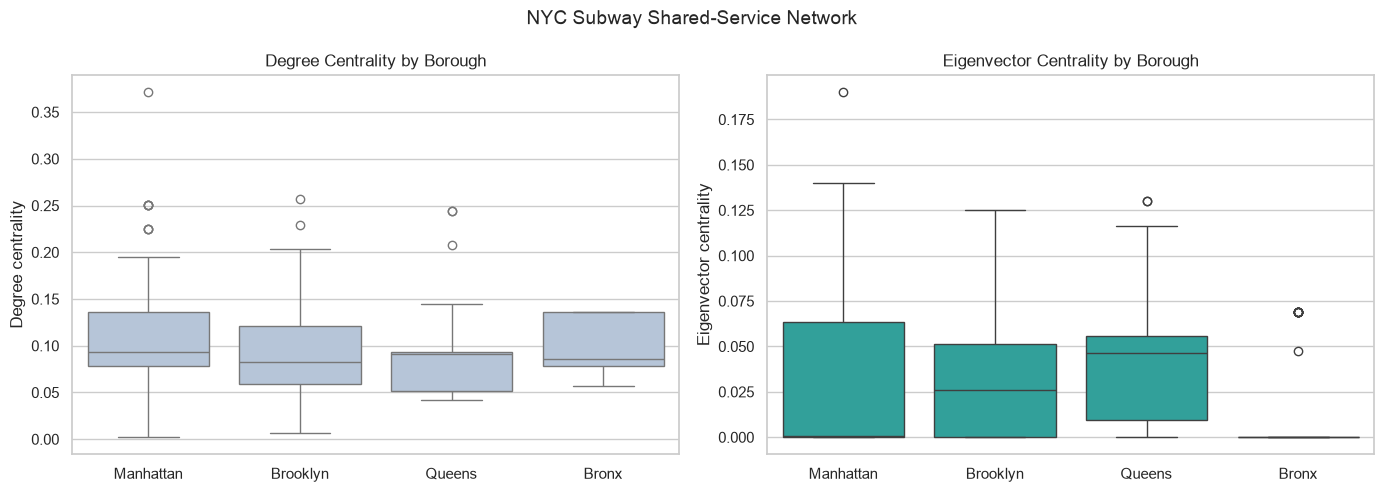

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=centrality_df,
    x="borough",
    y="degree_centrality",
    order=borough_order,
    color="lightsteelblue",
    ax=axes[0]
)

axes[0].set_title("Degree Centrality by Borough")
axes[0].set_xlabel("")
axes[0].set_ylabel("Degree centrality")

sns.boxplot(
    data=centrality_df,
    x="borough",
    y="eigenvector_centrality",
    order=borough_order,
    color="lightseagreen",
    ax=axes[1]
)

axes[1].set_title("Eigenvector Centrality by Borough")
axes[1].set_xlabel("")
axes[1].set_ylabel("Eigenvector centrality")

fig.suptitle("NYC Subway Shared-Service Network", fontsize=14)
plt.tight_layout()
plt.show()

## Highest-Ranked Stations

Stations are ranked separately by degree centrality and eigenvector centrality. Station IDs and route lists are included because different stations can share the same name.

The rankings describe shared-service connectivity rather than passenger volume or transfer activity. Stations with equivalent network connections can have identical centrality scores.

In [ ]:
ranking_columns = [
    "station_id",
    "stop_name",
    "borough",
    "daytime_routes",
    "component",
    "degree",
    "degree_centrality",
    "eigenvector_centrality"
]

top_degree = centrality_df.nlargest(
    10, "degree_centrality", keep="all"
)

top_eigenvector = (
    centrality_df.assign(
        eigenvector_ranking_key=centrality_df[
            "eigenvector_centrality"
        ].round(10)
    )
    .nlargest(10, "eigenvector_ranking_key", keep="all")
)

print("Highest-ranked stations by degree centrality:")
display(
    top_degree[ranking_columns].round(4).reset_index(drop=True)
)

print("Highest-ranked stations by eigenvector centrality:")
display(
    top_eigenvector[ranking_columns].round(4).reset_index(drop=True)
)

Highest-ranked stations by degree centrality:


,station_id,stop_name,borough,daytime_routes,component,degree,degree_centrality,eigenvector_centrality
0,167,W 4 St-Wash Sq,Manhattan,A B C D E F M,1,175,0.3715,0.1901
1,58,Coney Island-Stillwell Av,Brooklyn,D F N Q,1,121,0.2569,0.1249
2,225,47-50 Sts-Rockefeller Ctr,Manhattan,B D F M,1,118,0.2505,0.1399
3,226,42 St-Bryant Pk,Manhattan,B D F M,1,118,0.2505,0.1399
4,227,34 St-Herald Sq,Manhattan,B D F M,1,118,0.2505,0.1399
5,230,Broadway-Lafayette St,Manhattan,B D F M,1,118,0.2505,0.1399
6,261,Forest Hills-71 Av,Queens,E F M R,1,115,0.2442,0.1298
7,267,Jackson Hts-Roosevelt Av,Queens,E F M R,1,115,0.2442,0.1298
8,174,Jay St-MetroTech,Brooklyn,A C F,1,108,0.2293,0.1236
9,151,145 St,Manhattan,A B C D,1,106,0.2251,0.1190


Highest-ranked stations by eigenvector centrality:


,station_id,stop_name,borough,daytime_routes,component,degree,degree_centrality,eigenvector_centrality
0,167,W 4 St-Wash Sq,Manhattan,A B C D E F M,1,175,0.3715,0.1901
1,225,47-50 Sts-Rockefeller Ctr,Manhattan,B D F M,1,118,0.2505,0.1399
2,226,42 St-Bryant Pk,Manhattan,B D F M,1,118,0.2505,0.1399
3,227,34 St-Herald Sq,Manhattan,B D F M,1,118,0.2505,0.1399
4,230,Broadway-Lafayette St,Manhattan,B D F M,1,118,0.2505,0.1399
5,261,Forest Hills-71 Av,Queens,E F M R,1,115,0.2442,0.1298
6,267,Jackson Hts-Roosevelt Av,Queens,E F M R,1,115,0.2442,0.1298
7,58,Coney Island-Stillwell Av,Brooklyn,D F N Q,1,121,0.2569,0.1249
8,174,Jay St-MetroTech,Brooklyn,A C F,1,108,0.2293,0.1236
9,151,145 St,Manhattan,A B C D,1,106,0.2251,0.1190


### Station Ranking Results

W 4 St-Wash Sq has the highest degree centrality at 0.3715 and eigenvector centrality at 0.1901. Its seven listed routes connect it to 175 other stations, approximately 37.2% of the remaining network.

Coney Island-Stillwell Av ranks second by degree centrality, with 121 connections and a score of 0.2569. However, its eigenvector score of 0.1249 is below those of the B D F M stations in Manhattan and the E F M R stations in Queens. Although Coney Island has more direct connections, these other stations connect to neighbors with greater combined eigenvector centrality.

Stations sharing the same route sets have equivalent connections under this model, resulting in tied scores. The ranking tables contain 12 stations because 145 St, 125 St, and 59 St-Columbus Circle tie at the cutoff.

These rankings apply to individual station IDs. For example, the 34 St-Herald Sq entry represents its B D F M station record, rather than every service in the transfer complex. The results should therefore be interpreted as station-level shared-service connectivity.

## Magnitude of Borough Differences

Eta-squared is calculated for each centrality measure as the between-borough sum of squares divided by the total sum of squares.

Values closer to zero indicate that borough means account for little of the observed variation. Larger values indicate that more variation lies between borough means.

This is a descriptive comparison of the observed network, not a causal effect or a significance test. Stations share routes and connections, so their centrality scores are not independent observations. The eigenvector comparison is also affected by component membership.

In [16]:
def borough_effect_size(data, measure):
    overall_mean = data[measure].mean()

    group_summary = data.groupby("borough")[measure].agg(
        ["count", "mean"]
    )

    ss_between = (
        group_summary["count"]
        * (group_summary["mean"] - overall_mean) ** 2
    ).sum()

    ss_total = ((data[measure] - overall_mean) ** 2).sum()

    eta_squared = ss_between / ss_total if ss_total > 0 else np.nan

    return {
        "measure": measure,
        "eta_squared": eta_squared,
        "between_borough_percent": 100 * eta_squared
    }

effect_sizes = pd.DataFrame([
    borough_effect_size(centrality_df, "degree_centrality"),
    borough_effect_size(centrality_df, "eigenvector_centrality")
])

display(effect_sizes.round(4))

,measure,eta_squared,between_borough_percent
0,degree_centrality,0.0522,5.2199
1,eigenvector_centrality,0.0710,7.1030


### Magnitude of Borough Differences: Results

Eta-squared is 0.0522 for degree centrality, indicating that 5.22% of the total observed variation lies between borough means. The remaining 94.78% lies within boroughs.

For eigenvector centrality, eta-squared is 0.0710. Approximately 7.10% of the variation lies between borough means, while 92.90% lies within boroughs. This comparison also reflects differences in component membership across boroughs.

Although borough averages differ, borough grouping accounts for a relatively limited share of the overall variation. Stations within the same borough can have substantially different shared-service connections. These descriptive results do not establish statistical significance or causation.

## Network Visualization

The four connected components are displayed separately for readability. Node colors represent boroughs, and edges represent shared daytime routes.

Positions are determined by a spring layout and do not represent station geography. Each panel is scaled independently, so distances and apparent component sizes should not be compared across panels. All nodes and edges are included.

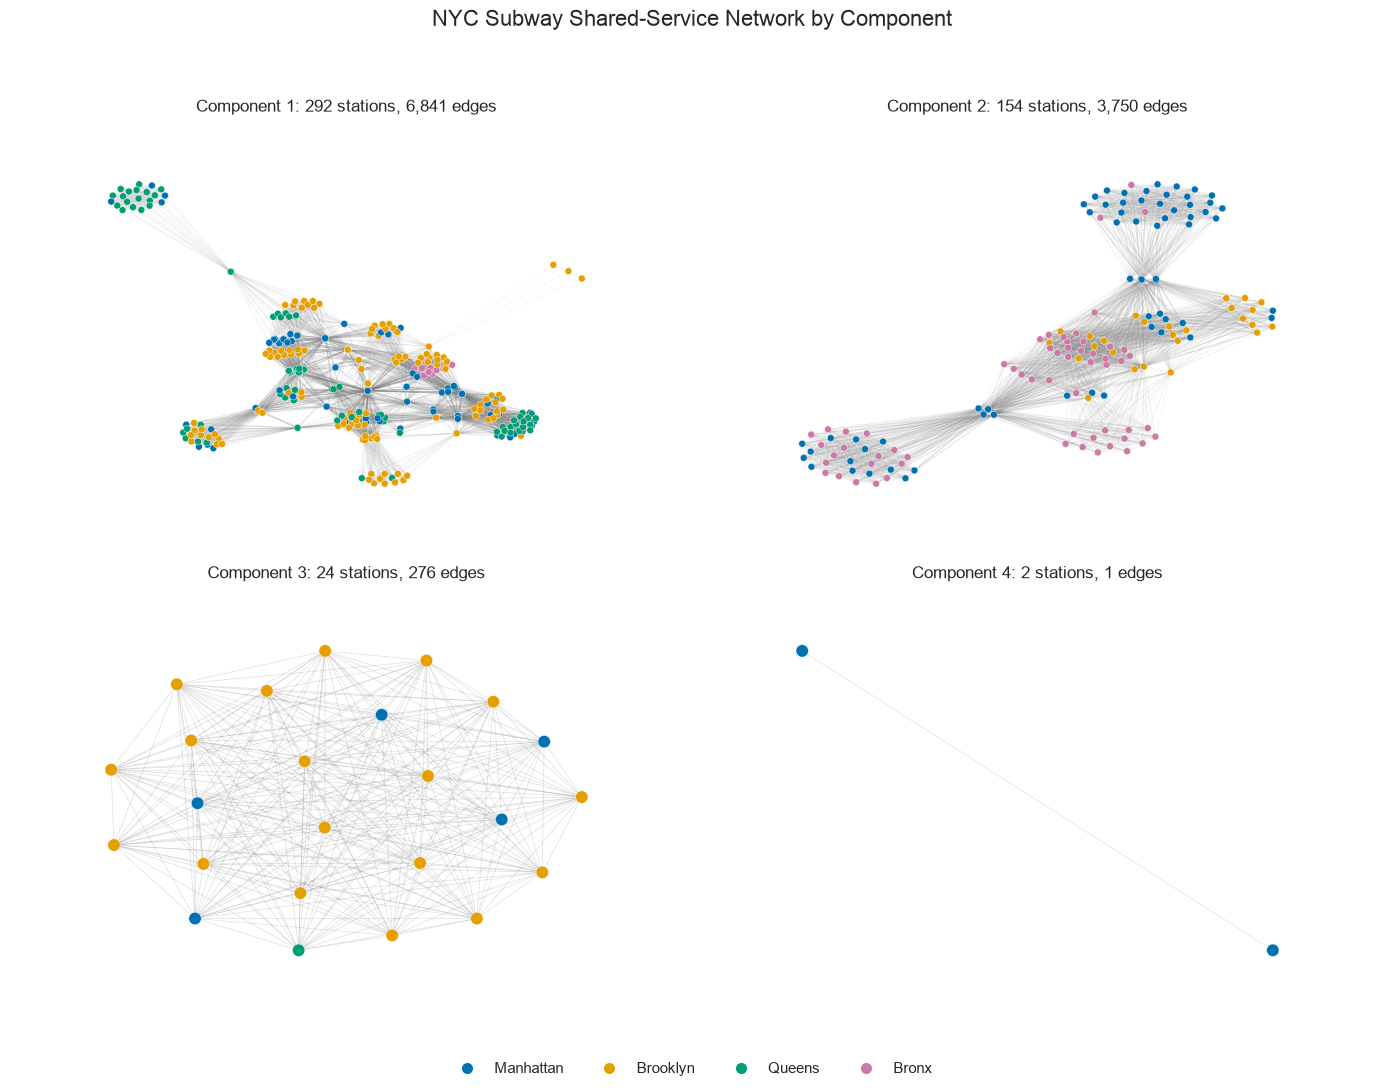

In [17]:
from matplotlib.lines import Line2D

borough_colors = {
    "Manhattan": "#0072B2",
    "Brooklyn": "#E69F00",
    "Queens": "#009E73",
    "Bronx": "#CC79A7"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for component_id, (nodes, ax) in enumerate(
    zip(components, axes.flat), start=1
):
    H = G.subgraph(nodes)
    node_order = sorted(H.nodes())

    positions = nx.spring_layout(
        H,
        seed=42,
        iterations=100,
        weight=None
    )

    nx.draw_networkx_edges(
        H,
        positions,
        ax=ax,
        edge_color="gray",
        alpha=0.08 if len(nodes) > 100 else 0.25,
        width=0.5
    )

    nx.draw_networkx_nodes(
        H,
        positions,
        nodelist=node_order,
        node_color=[
            borough_colors[H.nodes[node]["borough"]]
            for node in node_order
        ],
        node_size=25 if len(nodes) > 100 else 80,
        linewidths=0.3,
        edgecolors="white",
        ax=ax
    )

    ax.set_title(
        f"Component {component_id}: "
        f"{H.number_of_nodes()} stations, "
        f"{H.number_of_edges():,} edges"
    )
    ax.margins(0.15)
    ax.set_axis_off()

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="white",
        markersize=9,
        label=borough
    )
    for borough, color in borough_colors.items()
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False
)

fig.suptitle(
    "NYC Subway Shared-Service Network by Component",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Network Visualization Results

The visualization shows four disconnected components. The largest contains 292 stations and 6,841 edges, followed by a component with 154 stations and 3,750 edges.

The third component contains 24 stations and 276 edges, forming a complete graph in which every station connects to every other station. The fourth component consists of the two 42nd Street Shuttle stations connected by one edge.

These components result from the shared-service network definition. Transfer connections between separate station IDs are not included, so disconnected components do not indicate that passengers cannot travel between them.

## Limitations

This network represents shared daytime routes rather than physical track connections. Stations are connected whenever their route lists overlap, even if they are far apart. Route length and overlapping services therefore influence centrality.

The analysis uses individual station IDs rather than transfer complexes. Separate station IDs within a complex remain separate nodes, and transfer connections are not modeled. Results could differ under a complex-level network definition.

Full-network eigenvector centrality is concentrated in the component with the largest adjacency eigenvalue. Comparisons across boroughs consequently reflect both station connections and component membership. Near-zero eigenvector scores should not be interpreted as evidence of low transportation importance.

The dataset is a snapshot of listed daytime services. It does not capture service frequency, temporary disruptions, travel times, or every variation in scheduled stopping patterns.

Stations are connected through shared routes, making their centrality scores dependent. Eta-squared is used descriptively, and no claim of statistical significance or causation is made.

Ridership was not analyzed. The original proposal's question about predicting passenger activity remains a possible extension requiring a compatible ridership dataset and careful alignment of station and complex identifiers.

## Conclusion

This project constructed a shared-service network containing 472 NYC subway stations and 10,868 edges. Degree centrality and eigenvector centrality were calculated for every station and compared across Manhattan, Brooklyn, Queens, and the Bronx.

Manhattan had the highest mean degree centrality at 0.1128, supporting the proposed hypothesis about average shared-service connectivity. Queens had the highest mean eigenvector centrality at 0.0397, although this result was strongly influenced by its concentration of stations in the dominant component.

W 4 St-Wash Sq ranked first on both measures, sharing at least one listed route with 175 other stations. Differences elsewhere in the rankings showed that having more direct connections does not necessarily produce a higher eigenvector score.

Borough differences accounted for 5.22% of the observed variation in degree centrality and 7.10% in eigenvector centrality. Most variation occurred within boroughs, indicating that borough averages alone provide an incomplete description of station connectivity.

The findings demonstrate how network definitions and the choice of centrality measure affect the interpretation of subway connectivity. They describe shared-service structure rather than ridership, service quality, or overall transportation importance.

## References

Metropolitan Transportation Authority. *MTA Subway Stations*. New York State Open Data.  
https://data.ny.gov/Transportation/MTA-Subway-Stations/39hk-dx4f

NetworkX Developers. *eigenvector_centrality*. NetworkX documentation.  
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.eigenvector_centrality.html